## **Customer Churn and Survival Analysis.**

## **Load data and drop leakage prone columns.**

In [1]:
import os
import pandas as pd
import numpy as np

DATASETS_PATH = os.getenv("DATASETS_PATH")
DATASETS_PATH = DATASETS_PATH + "/CustomerChurn/"

data_df = pd.read_excel(DATASETS_PATH + "Telco_customer_churn.xlsx")

data_df = data_df.drop(columns=["Churn Score", "CLTV", "Churn Reason"])

print("Data: ")
print(data_df)


Data: 
      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gen

## **Convert columns with string values that have more than one value to one-hot-encoding.**

In [2]:
# The column "Total Charges" has some missing values, which result in NaNs, so it has to be fixed
data_df["Total Charges"] = pd.to_numeric(data_df["Total Charges"], errors="coerce")
data_df["Total Charges"] = data_df["Total Charges"].fillna(0.0)

# Add some new features describing wether the contract is short-term (which is a high risk for churn)
data_df["Short_Term_Contract"] = (
    (data_df["Contract"] == "Month-to-month").astype(int)
)

data_df["Contract_Tenure_Risk"] = (
    data_df["Short_Term_Contract"] / (data_df["Tenure Months"] + 1)
)

# Define new features describing wether a customer uses additional services.
risk_services = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

data_df["Missing_Services"] = (data_df[risk_services] == "No").sum(axis=1)

encoded_df = data_df.drop(columns=["Churn Value", "Churn Label", "CustomerID","Country","State","City","Lat Long", "Latitude", "Longitude", "Count", "Zip Code"])
y = data_df["Churn Value"]

for col in encoded_df.columns:
    if pd.api.types.is_string_dtype(data_df[col]):
        print(col)

Gender
Senior Citizen
Partner
Dependents
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection
Tech Support
Streaming TV
Streaming Movies
Contract
Paperless Billing
Payment Method


In [3]:
X_encoded = pd.get_dummies(encoded_df, drop_first=True)
print(X_encoded)

      Tenure Months  Monthly Charges  Total Charges  Short_Term_Contract  \
0                 2            53.85         108.15                    1   
1                 2            70.70         151.65                    1   
2                 8            99.65         820.50                    1   
3                28           104.80        3046.05                    1   
4                49           103.70        5036.30                    1   
...             ...              ...            ...                  ...   
7038             72            21.15        1419.40                    0   
7039             24            84.80        1990.50                    0   
7040             72           103.20        7362.90                    0   
7041             11            29.60         346.45                    1   
7042             66           105.65        6844.50                    0   

      Contract_Tenure_Risk  Missing_Services  Gender_Male  Senior Citizen_Yes  \
0     

In [4]:
# Print resulting features
print(X_encoded.columns)

Index(['Tenure Months', 'Monthly Charges', 'Total Charges',
       'Short_Term_Contract', 'Contract_Tenure_Risk', 'Missing_Services',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='str')


In [5]:
baseline_dict = {}

for col in encoded_df.select_dtypes(include=["string", "category"]).columns:
    categories = sorted(encoded_df[col].dropna().unique())
    baseline_dict[col] = categories[0]

print(baseline_dict)

{'Gender': 'Female', 'Senior Citizen': 'No', 'Partner': 'No', 'Dependents': 'No', 'Phone Service': 'No', 'Multiple Lines': 'No', 'Internet Service': 'DSL', 'Online Security': 'No', 'Online Backup': 'No', 'Device Protection': 'No', 'Tech Support': 'No', 'Streaming TV': 'No', 'Streaming Movies': 'No', 'Contract': 'Month-to-month', 'Paperless Billing': 'No', 'Payment Method': 'Bank transfer (automatic)'}


## **Divide into train and test datasets.**

In [6]:
from sklearn.model_selection import train_test_split

# Add the column with zip codes in order to encode it with encounter frequency
X_encoded["Zip Code"] = data_df["Zip Code"]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

freq_map = X_train["Zip Code"].value_counts(normalize=True)

X_train["ZipCode_freq"] = X_train["Zip Code"].map(freq_map)
X_test["ZipCode_freq"] = X_test["Zip Code"].map(freq_map)

min_freq = freq_map.min()

X_test["ZipCode_freq"].fillna(min_freq)
X_train["ZipCode_freq"].fillna(min_freq)

X_train = X_train.drop(columns = "Zip Code")
X_test = X_test.drop(columns = "Zip Code")


## **Conduct logistic regression for baseline.**

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=100000)
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

y_proba_lr = model.predict_proba(X_test)[:, 1]

threshold_lr = 0.5

y_pred_lr = (y_proba_lr >= threshold_lr).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

from sklearn.metrics import roc_auc_score

print("ROC-AUC: ")
roc_auc_score(y_test, y_proba_lr)

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1009
           1       0.72      0.57      0.64       400

    accuracy                           0.81      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.81      0.81      0.81      1409

ROC-AUC: 


0.8598389494549059

## **Conduct classification with Random Forest.**

In [8]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestClassifier

import warnings
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning

warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="One or more of the test scores are non-finite")

param_dist = {
    "n_estimators": [100, 200, 300, 500, 600, 700],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [True],
    "max_samples": [0.5, 0.65, 0.8, None]
}

rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

halving_search = HalvingRandomSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    scoring="roc_auc",
    cv=5,
    factor=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

halving_search.fit(X_train, y_train)

best_rf = halving_search.best_estimator_

print("Best params:", halving_search.best_params_)
print()

from sklearn.metrics import classification_report, roc_auc_score

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 20
max_resources_: 5634
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 281
n_resources: 20
Fitting 5 folds for each of 281 candidates, totalling 1405 fits
----------
iter: 1
n_candidates: 94
n_resources: 60
Fitting 5 folds for each of 94 candidates, totalling 470 fits
----------
iter: 2
n_candidates: 32
n_resources: 180
Fitting 5 folds for each of 32 candidates, totalling 160 fits
----------
iter: 3
n_candidates: 11
n_resources: 540
Fitting 5 folds for each of 11 candidates, totalling 55 fits
----------
iter: 4
n_candidates: 4
n_resources: 1620
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 5
n_candidates: 2
n_resources: 4860
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best params: {'n_estimators': 600, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_samples': None, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

   

## **Conduct classification with XGBoost model.**

In [9]:
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [3, 5, 7, 10, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_lambda": [0.5, 1, 2, 5]
}

from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

halving_search = HalvingRandomSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    scoring="roc_auc",
    cv=5,
    factor=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

halving_search.fit(X_train, y_train)

best_xgb = halving_search.best_estimator_

print("Best params:", halving_search.best_params_)

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 20
max_resources_: 5634
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 281
n_resources: 20
Fitting 5 folds for each of 281 candidates, totalling 1405 fits
----------
iter: 1
n_candidates: 94
n_resources: 60
Fitting 5 folds for each of 94 candidates, totalling 470 fits
----------
iter: 2
n_candidates: 32
n_resources: 180
Fitting 5 folds for each of 32 candidates, totalling 160 fits
----------
iter: 3
n_candidates: 11
n_resources: 540
Fitting 5 folds for each of 11 candidates, totalling 55 fits
----------
iter: 4
n_candidates: 4
n_resources: 1620
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 5
n_candidates: 2
n_resources: 4860
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best params: {'subsample': 0.6, 'reg_lambda': 0.5, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 

## **Conduct classification with lightGBM model.**

In [10]:
from lightgbm import LGBMClassifier

param_dist = {
    "n_estimators": [10, 50, 100, 150, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [7, 15, 31, 50, 70, 100],
    "max_depth": [-1, 1, 5, 10, 15],
    "min_child_samples": [5, 10, 20, 30, 50],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "reg_lambda": [0, 0.2, 0.5, 1, 2, 5]
}

lgb_model = LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

halving_search = HalvingRandomSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    scoring="roc_auc",
    cv=5,
    factor=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

halving_search.fit(X_train, y_train)

best_lgb = halving_search.best_estimator_

print("Best params:", halving_search.best_params_)

y_pred_lgb = best_lgb.predict(X_test)
y_proba_lgb = best_lgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgb))

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 20
max_resources_: 5634
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 281
n_resources: 20
Fitting 5 folds for each of 281 candidates, totalling 1405 fits
----------
iter: 1
n_candidates: 94
n_resources: 60
Fitting 5 folds for each of 94 candidates, totalling 470 fits
----------
iter: 2
n_candidates: 32
n_resources: 180
Fitting 5 folds for each of 32 candidates, totalling 160 fits
----------
iter: 3
n_candidates: 11
n_resources: 540
Fitting 5 folds for each of 11 candidates, totalling 55 fits
----------
iter: 4
n_candidates: 4
n_resources: 1620
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 5
n_candidates: 2
n_resources: 4860
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1469, number of negative: 4165
[LightGBM] [Info] A

## **Conclusion of Churn Probability Modeling.**
Several classification models were evaluated for customer churn prediction, including Logistic Regression, Random Forest, XGBoost, and LightGBM.

All models achieved similar **ROC-AUC scores (~0.86)**, indicating comparable ability to distinguish between churned and retained customers. However, significant differences were observed in precision-recall trade-offs.

Logistic Regression demonstrated higher precision but substantially lower recall for churned customers, meaning it failed to identify a large proportion of at-risk customers. In contrast, tree-based ensemble models (Random Forest, XGBoost, LightGBM) significantly improved recall, making them more suitable for churn detection tasks.

Among these, **LightGBM achieved the highest recall (0.81) for the churn class**, indicating the strongest ability to identify customers at risk of leaving. This comes at the cost of lower precision, implying more false positives.

From a business perspective, where missing a churner is typically more costly than incorrectly flagging a loyal customer, LightGBM provides the most effective model for churn prediction.

However, Logistic Regression remains valuable as a benchmark due to its interpretability and stable performance.

Further improvements could be achieved by optimizing the classification threshold to better align with business cost trade-offs.

## **Conduct static survival analysis.**

Prepare features and target. There should be no leakage by using columns which are derived from monthly tenure.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

X_train_survival = X_train.drop(
    columns=['Tenure Months','Total Charges','Contract_Tenure_Risk']
)

X_test_survival = X_test.drop(
    columns=['Tenure Months','Total Charges','Contract_Tenure_Risk']
)

y_train_survival = np.array(
    [
        (bool(e), float(t))
        for e, t in zip(y_train, X_train["Tenure Months"])
    ],
    dtype=[("event", "bool"), ("time", "float")]
)

y_test_survival = np.array(
    [
        (bool(e), float(t))
        for e, t in zip(y_test, X_test["Tenure Months"])
    ],
    dtype=[("event", "bool"), ("time", "float")]
)


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("cox", CoxPHSurvivalAnalysis(alpha=1.0))  # ← add regularization
])

pipeline.fit(X_train_survival, y_train_survival)

# Predictions = risk scores
train_pred = pipeline.predict(X_train_survival)
test_pred = pipeline.predict(X_test_survival)

train_cindex = concordance_index_censored(
    y_train_survival["event"], y_train_survival["time"], train_pred
)[0]

test_cindex = concordance_index_censored(
    y_test_survival["event"], y_test_survival["time"], test_pred
)[0]

print(f"Train C-index: {train_cindex:.4f}")
print(f"Test C-index:  {test_cindex:.4f}")


Train C-index: 0.8700
Test C-index:  0.8698


In [25]:
cox_model = pipeline.named_steps["cox"]

coefficients = pd.Series(cox_model.coef_, index=X_test_survival.columns)

hazard_ratios = np.exp(coefficients).sort_values(ascending=False)

print(hazard_ratios)

Short_Term_Contract                       2.054911
Monthly Charges                           1.551845
Payment Method_Electronic check           1.280934
Missing_Services                          1.263452
Payment Method_Mailed check               1.255361
Paperless Billing_Yes                     1.111434
Multiple Lines_No phone service           1.021633
ZipCode_freq                              1.002341
Streaming Movies_No internet service      0.996052
Tech Support_No internet service          0.996052
Device Protection_No internet service     0.996052
Streaming TV_No internet service          0.996052
Internet Service_No                       0.996052
Online Backup_No internet service         0.996052
Online Security_No internet service       0.996052
Phone Service_Yes                         0.978825
Payment Method_Credit card (automatic)    0.966308
Internet Service_Fiber optic              0.956040
Gender_Male                               0.955333
Senior Citizen_Yes             

The **Cox proportional hazards model** revealed several strong drivers of customer churn risk:

Contract duration is the most influential factor, with short-term contracts doubling churn risk, while two-year contracts reduce churn risk by more than 50%.
Higher monthly charges significantly increase churn probability, indicating price sensitivity among customers.
Customers with additional services such as online security, tech support, and backup show substantially lower churn risk, highlighting the importance of service bundling.
Customers using electronic or mailed check payment methods exhibit higher churn risk compared to automated payment methods.
Household-related attributes such as having dependents or a partner are associated with lower churn risk, suggesting higher customer stability.

Overall, the results show that churn is strongly driven by contract structure, pricing, and service engagement.

In the following code, we transform the trained Cox survival model into a customer risk scoring and segmentation system, and visualize how churn risk evolves over time for different customer groups.

Based on the normalized risk score, customers are divided into three groups:

* **Low Risk (0–33)** → stable customers
* **Medium Risk (33–66)** → moderate churn risk
* **High Risk (66–100)** → high churn risk

This converts model outputs into actionable business segments.

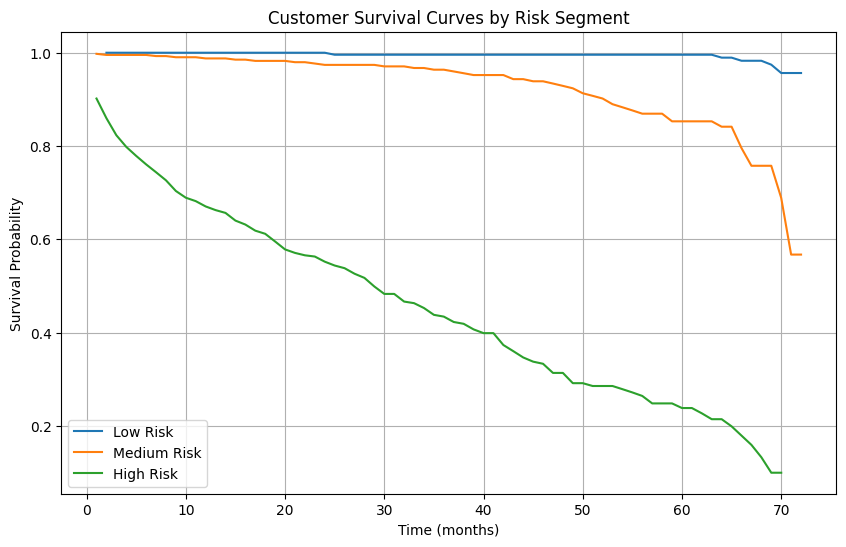

In [27]:
risk_scores = pipeline.predict(X_test_survival)

df_test = X_test_survival.copy()
df_test["risk_score"] = risk_scores

df_test["risk_score_norm"] = (
    100 * (df_test["risk_score"] - df_test["risk_score"].min())
    / (df_test["risk_score"].max() - df_test["risk_score"].min())
)

def risk_segment(score):
    if score < 33:
        return "Low Risk"
    elif score < 66:
        return "Medium Risk"
    else:
        return "High Risk"

df_test["risk_segment"] = df_test["risk_score_norm"].apply(risk_segment)

df_test["expected_risk_rank"] = df_test["risk_score"].rank(ascending=False)

df_test["risk_segment"].value_counts(normalize=True)

df_test.groupby("risk_segment")["Monthly Charges"].mean()

df = df_test.copy()

df["time"] = y_test_survival["time"]
df["event"] = y_test_survival["event"].astype(int)

def kaplan_meier(data, time_col, event_col):
    df = data[[time_col, event_col]].copy()
    
    # unique event times
    times = np.sort(df[time_col].unique())
    
    survival_prob = []
    survival = 1.0
    
    for t in times:
        at_risk = df[df[time_col] >= t]
        events = df[(df[time_col] == t) & (df[event_col] == 1)]
        
        n_i = len(at_risk)
        d_i = len(events)
        
        if n_i > 0:
            survival *= (1 - d_i / n_i)
        
        survival_prob.append(survival)
    
    return pd.DataFrame({
        "time": times,
        "survival": survival_prob
    })

segments = ["Low Risk", "Medium Risk", "High Risk"]

curves = {}

for seg in segments:
    subset = df[df["risk_segment"] == seg]
    curves[seg] = kaplan_meier(subset, "time", "event")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for seg, curve in curves.items():
    plt.plot(curve["time"], curve["survival"], label=seg)

plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.title("Customer Survival Curves by Risk Segment")
plt.legend()
plt.grid(True)
plt.show()

Kaplan–Meier survival curves were implemented from first principles without using specialized survival analysis libraries, ensuring full transparency of the underlying probability estimation process.

## **Conclusions of Survival-Analysis.**

* Churn is strongly time-structured: <br/>
    Customer churn is not random — it follows clear temporal patterns. The survival model shows that churn risk evolves predictably over tenure, making      time-to-churn modeling more informative than binary classification alone.
* The most important drivers of churn risk are:
    * Contract type is a strongest predictor
        * short-term contracts significantly increase churn hazard
        * long-term contracts strongly improve retention
    * Monthly charges show strong price sensitivity signal
        * higher charges increase churn risk
    * Service adoption
        * customers using support and security services are significantly more stable
        * lack of services increases churn likelihood
    * Payment behavior
        * electronic and manual payment methods are associated with higher churn risk
* Customer segmentation is meaningful and actionable:<br/>
    The risk scoring system successfully separates customers into groups with: low, medium and high risk of churn. These groups show clearly different survival trajectories, confirming the validity of the risk model.
* Survival curves validate model behavior:<br/>
  Manually constructed Kaplan–Meier curves show:
    * steep early decline for high-risk customers
    * gradual decay for medium-risk customers
    * stable long-term retention for low-risk customers<br/>
      
    This confirms that the model captures realistic churn dynamics over time.